In [3]:
import json
from shapely import geometry
import rioxarray as rioxr
import xarray as xr
from datacube.utils.dask import start_local_dask
from datacube.utils.geometry import CRS, Geometry, GeoBox
from datacube import Datacube
# import awswrangler as wr
import re
from rasterio import features
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from os import path
import geopandas as gpd

In [5]:
with open("au-grid-extended-clipped.geojson", "r") as f:
    features = json.load(f)

id_match = {}
for f in features['features']:
    id_match[f['properties']['input_region_code']] = f['properties']['method_region_code']

In [ ]:
dc = Datacube(config=None)

In [ ]:
def gqa_predicate(ds):
    return ds.metadata.gqa_iterative_mean_xy <= 1

In [ ]:
client = start_local_dask(n_workers=1, threads_per_worker=60, memory_limit='478GB')
client

In [ ]:
client.close()

In [7]:
products_list = {"ls5": ("ga_ls5t_gm_cyear_3","ga_ls5t_nbart_gm_cyear_3", "ga_ls5t_ard_3"),
                "ls7": ("ga_ls7e_gm_cyear_3","ga_ls7e_nbart_gm_cyear_3", "ga_ls7e_ard_3"),
                "ls8": ("ga_ls8cls9c_gm_cyear_3", "ga_ls8c_nbart_gm_cyear_3", "ga_ls8c_ard_3"),
                }

In [ ]:
for sensor, prods in products_list.items():
    print(f"sensor {sensor}")
    for key, val in id_match.items():
        n_datasets = dc.find_datasets(product=prods[0], region_code=key, measurements=["count"])
        if n_datasets == []:
            continue
        print(f"{key}: {val}")
        ls5_query = {'geopolygon': Geometry(n_datasets[0].metadata_doc['geometry'],
                                       crs="EPSG:3577")}
        n_gm = dc.load(datasets=n_datasets, measurements=["count"], dask_chunks={'time':1, "x":-1, "y":-1})
        n_gm.load()
        clear_freq = []
        if sensor == "ls8":
            nbart_prod = [prods[2], "ga_ls9c_ard_3"]
        else:
            nbart_prod = prods[2]
        for i in range(len(n_gm.time)):
            ls5_datasets = dc.find_datasets(product=nbart_prod, **ls5_query,
                                            **{"time": str(n_gm.time.data[i].astype("datetime64[Y]"))},
                                            dataset_predicate=gqa_predicate)
            ls5_mask = np.zeros(n_gm["count"].shape[1:])
            for ds in ls5_datasets:
                ds_valid_geom = Geometry(ds.metadata_doc['grid_spatial']['projection']['valid_data'], 
                               crs=ds.metadata_doc['grid_spatial']['projection']['spatial_reference'])
                ls5_mask += features.geometry_mask([ls5_query['geopolygon'].intersection(ds_valid_geom.to_crs(ls5_query['geopolygon'].crs))],
                                   out_shape=n_gm["count"].shape[1:],
                                   transform=n_gm.affine,
                                   all_touched=False,
                                   invert=True).astype('int32')
            freq = (n_gm["count"].isel(time=i) / ls5_mask)
            freq = freq.where(freq!=np.inf, 1)
            clear_freq += [freq.mean()]
        clear_freq = xr.concat(clear_freq, dim="time")
        clear_freq.drop("spatial_ref").to_dataframe().to_csv(sensor+"_gm_clear_freq/n_"+key+"_gm_clear_freq.csv")

        c_datasets = dc.find_datasets(product=prods[1], region_code=val)
        c_gm = dc.load(datasets=c_datasets, measurements=["count"], dask_chunks={'time':1, "x":-1, "y":-1})
        c_gm.load()

        clear_freq = []
        for i in range(len(c_gm.time)):
            if sensor == "ls8" and int(str(c_gm.time.data[i].astype("datetime64[Y]")))>=2021:
                print("with gqa")
                ls5_datasets = dc.find_datasets(product=prods[2], **ls5_query,
                                            **{"time": str(c_gm.time.data[i].astype("datetime64[Y]"))},
                                               dataset_predicate=gqa_predicate)
            else:
                ls5_datasets = dc.find_datasets(product=prods[2], **ls5_query,
                                            **{"time": str(c_gm.time.data[i].astype("datetime64[Y]"))},
                                               dataset_predicate=gqa_predicate)
            ls5_mask = np.zeros(c_gm["count"].shape[1:])
            for ds in ls5_datasets:
                ds_valid_geom = Geometry(ds.metadata_doc['grid_spatial']['projection']['valid_data'], 
                               crs=ds.metadata_doc['grid_spatial']['projection']['spatial_reference'])
                ls5_mask += features.geometry_mask([ls5_query['geopolygon'].intersection(ds_valid_geom.to_crs(ls5_query['geopolygon'].crs))],
                                   out_shape=c_gm["count"].shape[1:],
                                   transform=c_gm.affine,
                                   all_touched=False,
                                   invert=True).astype('int32')
            freq = (c_gm["count"].isel(time=i) / ls5_mask)
            freq = freq.where(freq!=np.inf, 1)
            clear_freq += [freq.mean()]
        clear_freq = xr.concat(clear_freq, dim="time")
        clear_freq.drop("spatial_ref").to_dataframe().to_csv(sensor+"_gm_clear_freq/c_"+val+"_gm_clear_freq.csv")

In [75]:
grid_df = gpd.read_file("au-grid-extended-clipped.geojson")
aus_shape = gpd.read_file("aus_map/cstauscd_r_3577.shp")

In [190]:
clear_freq = pd.DataFrame()
clear_freq_old = pd.DataFrame()
for sensor, prods in products_list.items():
    print(f"sensor {sensor}")
    for _, items in grid_df[["input_region_code", "method_region_code", "input_ix", "input_iy"]].iterrows():
        if not path.exists(sensor+"_gm_clear_freq/n_"+items.iloc[0]+"_gm_clear_freq.csv"):
            continue
        tmp_freq = pd.read_csv(sensor+"_gm_clear_freq/n_"+items.iloc[0]+"_gm_clear_freq.csv")
        tmp_freq["region_id"] = items.iloc[0]
        tmp_freq["sensor"] = sensor
        tmp_freq['input_ix'] = items.iloc[2]
        tmp_freq["input_iy"] = items.iloc[3]
        clear_freq = pd.concat([clear_freq, tmp_freq], ignore_index=True)
        tmp_freq = pd.read_csv(sensor+"_gm_clear_freq/c_"+items.iloc[1]+"_gm_clear_freq.csv")
        tmp_freq["region_id"] = items.iloc[0]
        tmp_freq["sensor"] = sensor
        tmp_freq['input_ix'] = items.iloc[2]
        tmp_freq["input_iy"] = items.iloc[3]
        clear_freq_old = pd.concat([clear_freq_old, tmp_freq], ignore_index=True)

sensor ls5
sensor ls7
sensor ls8


In [191]:
clear_freq_old["count"] = clear_freq_old["count"].clip(0, 1)

In [192]:
clear_freq = pd.merge(clear_freq, clear_freq_old, how="inner", on=["region_id", "sensor", "input_ix", "input_iy", "time"])

In [193]:
clear_freq = pd.merge(clear_freq, grid_df, how="left", on=["input_ix", "input_iy"])

clear_freq = gpd.GeoDataFrame(clear_freq)

clear_freq = clear_freq.set_geometry("geometry")

In [224]:
clear_freq["count_d"] = (clear_freq["count_y"] - clear_freq["count_x"])/clear_freq["count_y"]

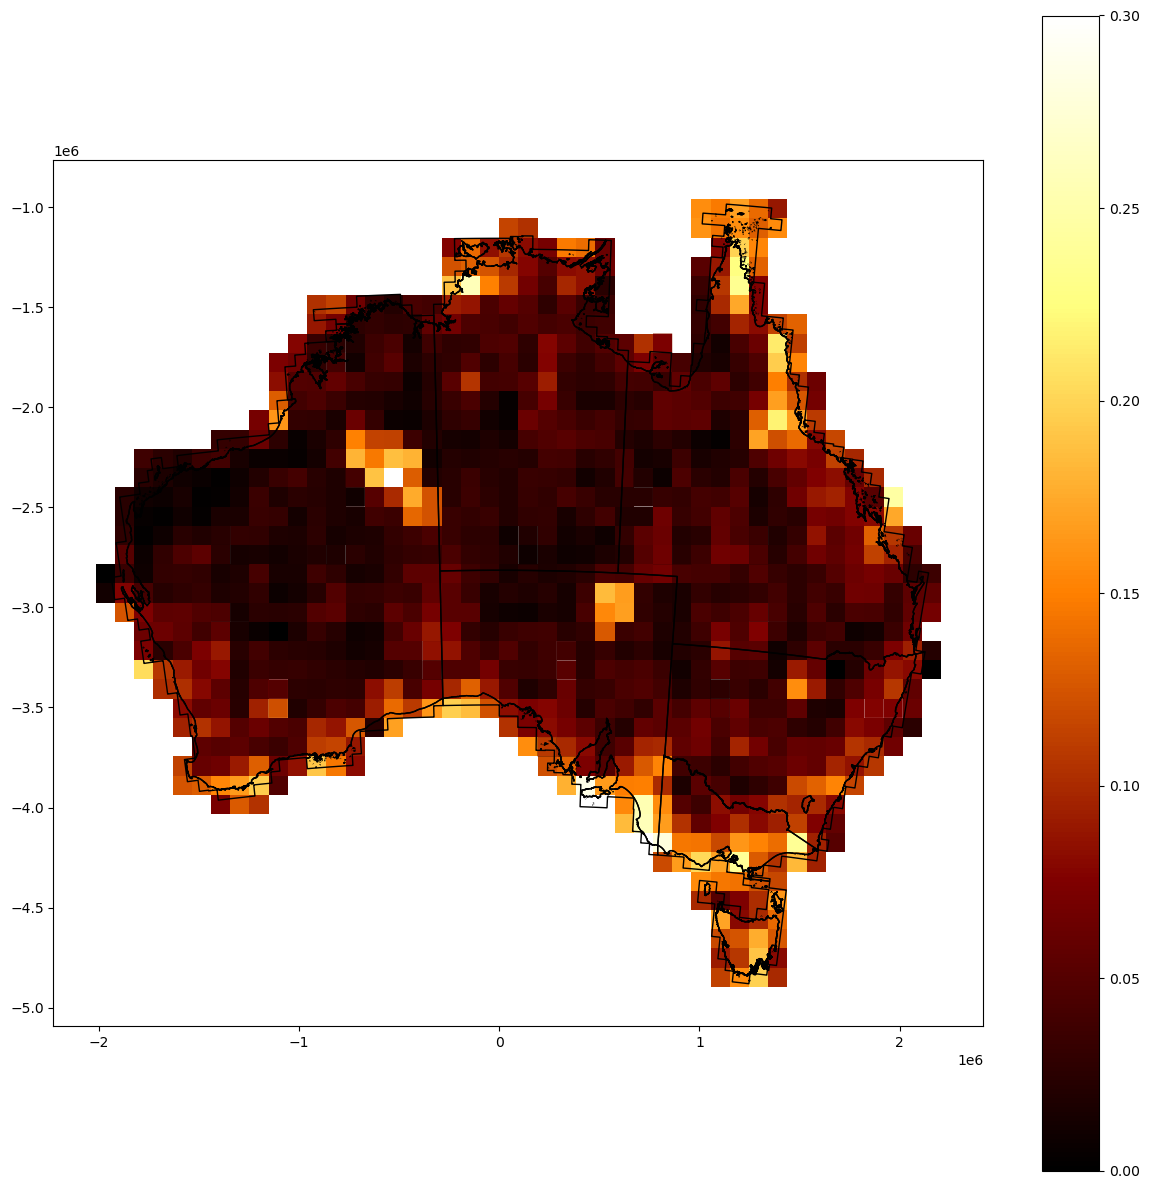

In [234]:
f, ax = plt.subplots(1, figsize=(15, 15))
clear_freq[(clear_freq['time'] < "1988") & (clear_freq['time'] > "1986")].to_crs(epsg=3577).plot(column='count_d', cmap='afmhot' ,ax=ax,
                                                                                                legend=True,
                                                                                                vmin=0,
                                                                                                vmax=0.3)
ax = aus_shape.plot(ax=ax, facecolor="none")

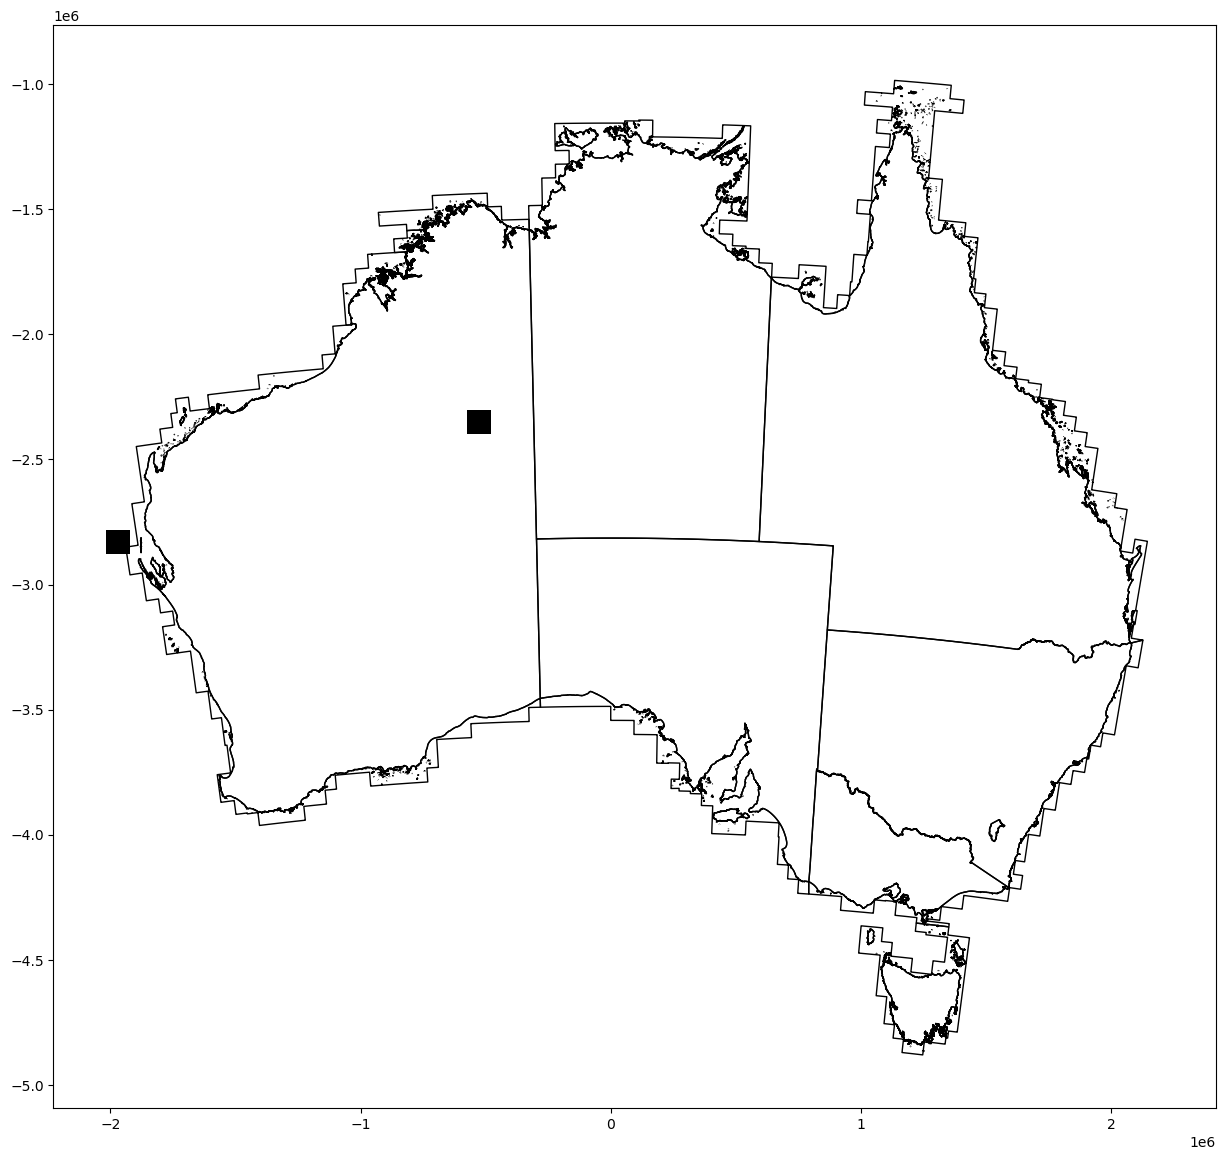

In [256]:
f, ax = plt.subplots(1, figsize=(15, 15))
clear_freq[(clear_freq['time'] < "2006") & (clear_freq['time'] > "2004")
          & (clear_freq['sensor'] == "ls7")].to_crs(epsg=3577).plot(column='count_x', cmap='afmhot' ,ax=ax,
                                                                                                legend=False, 
                                                                                                vmin=0,
                                                                                                vmax=0.001)
ax = aus_shape.plot(ax=ax, facecolor="none")

In [243]:
def animate(frame, sensor="ls5", start=1986):
    year = frame

    ax.clear()
    # plt.clf()
    if frame == start:
        cbar = True
    else:
        cbar = False
    y_data = clear_freq[(clear_freq['time'] < str(year+1)) & (clear_freq['time'] > str(year-1))
              & (clear_freq['sensor'] == sensor)]
    y_data.to_crs(epsg=3577).plot(column='count_d', cmap='afmhot' ,ax=ax,
                                legend=cbar, vmin=0, vmax=0.3)
    aus_shape.plot(ax=ax, facecolor="none")
    ax.set_title(f"{sensor.upper()} year={year}")
    ax.set(xticklabels=[], yticklabels=[], xlabel=None, ylabel=None)
    ax.tick_params(bottom=False, left=False)
    # return ax

In [237]:
def init_anim():
    ax.clear()
    

In [37]:
# %matplotlib inline
# %matplotlib notebook
import matplotlib.pyplot as plt
from matplotlib import animation
from functools import partial


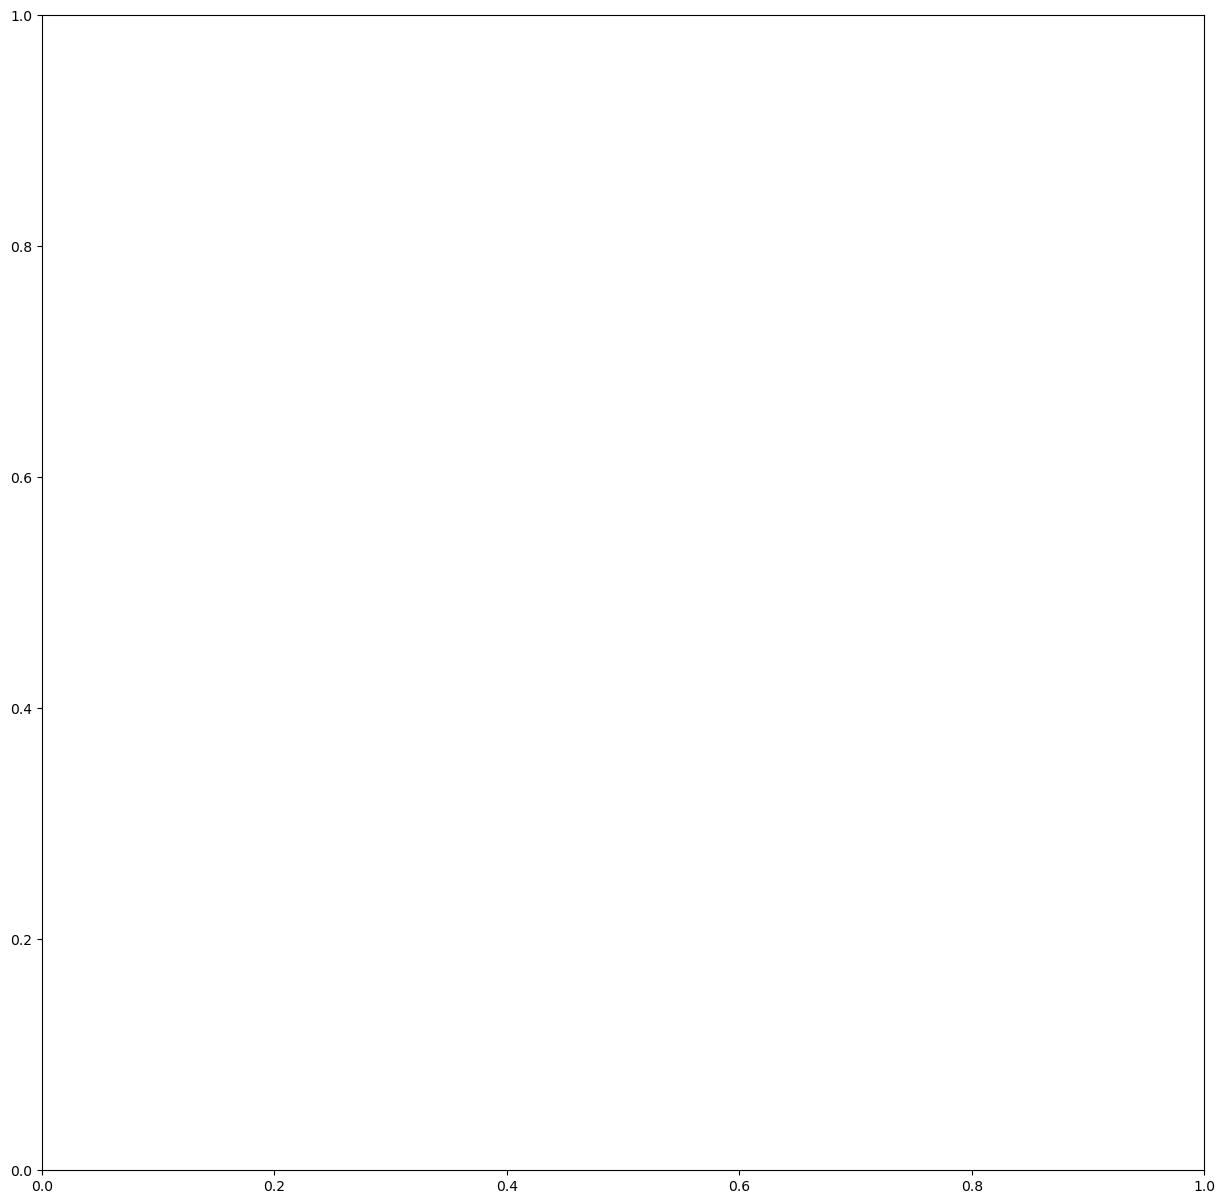

In [248]:
fig, ax = plt.subplots(1, figsize=(15, 15))
anim = animation.FuncAnimation(fig, partial(animate, sensor="ls7", start=1999), init_func=init_anim,
                               frames=np.sort(pd.DatetimeIndex(clear_freq[clear_freq['sensor'] == 'ls7']['time']).year.unique().values),
                               repeat = False, 
                               interval=400)

In [249]:
anim.save("ls7_gm_cloud_increase.gif", writer=animation.PillowWriter(fps=2))

<Figure size 640x480 with 0 Axes>